<a href="https://colab.research.google.com/github/Salaheddine464/Projet-IA-CI-Bouchra-Zekkari---Douae-Amrani---Salaheddine-Hajji/blob/main/Python_Script_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Bibliothèques importées avec succès
✅ Dataset généré : 23 campagnes × 11 variables
  campagne  pluviometrie_mm  production_nat_kt  besoins_totaux_kt  \
0  2001/02              260        4624.694280        8632.184518   
1  2002/03              190        3679.075415        8489.801285   
2  2003/04              330        6549.211943        8905.139604   
3  2004/05              280        4946.338650        8819.872262   
4  2005/06              220        3866.345217        8991.661250   

   deficit_cerealier_kt  prix_ble_cbot_usd  prix_orge_usd  taux_change_mad  \
0           4007.490238                130      87.295679             10.6   
1           4810.725869                115      92.292672             10.8   
2           2355.927661                125      94.419342             10.9   
3           3873.533612                145     107.684624             11.0   
4           5125.316033                160     129.693410             10.8   

   subvention_mmdh  volume_impo

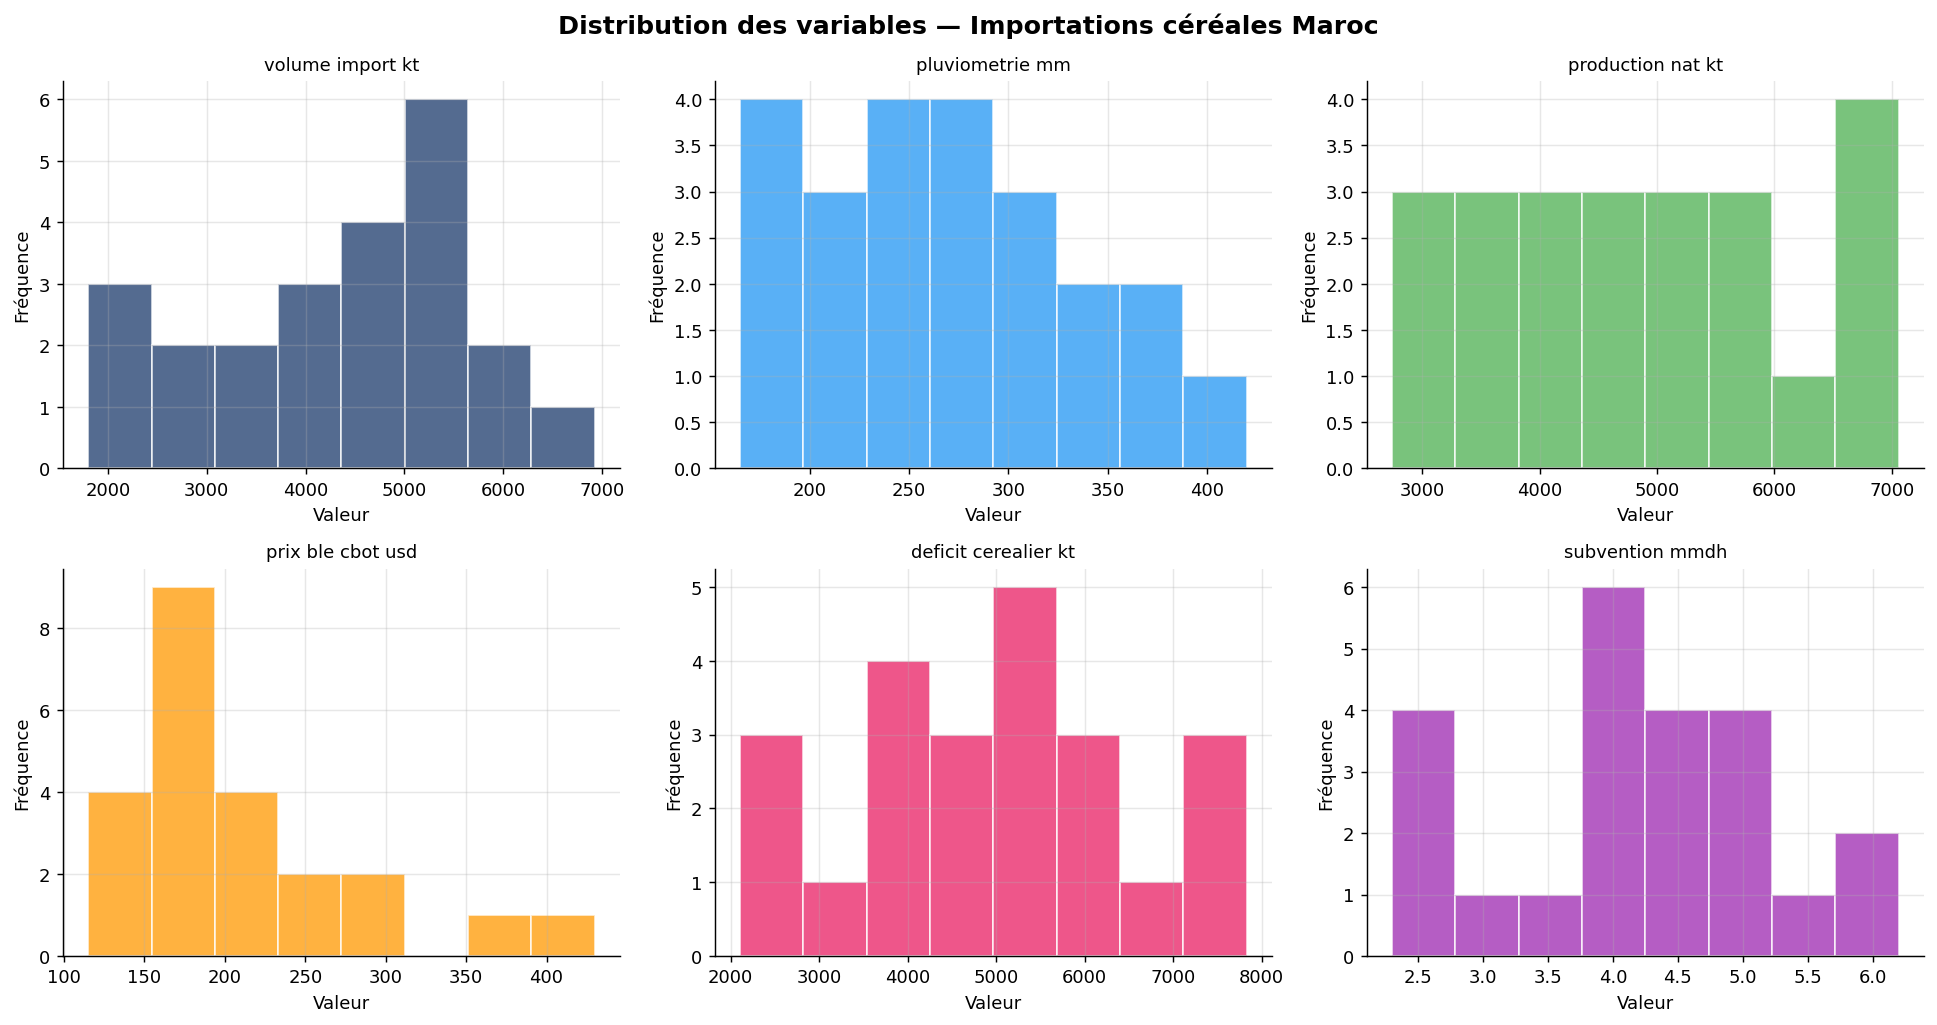

✅ Histogrammes affichés


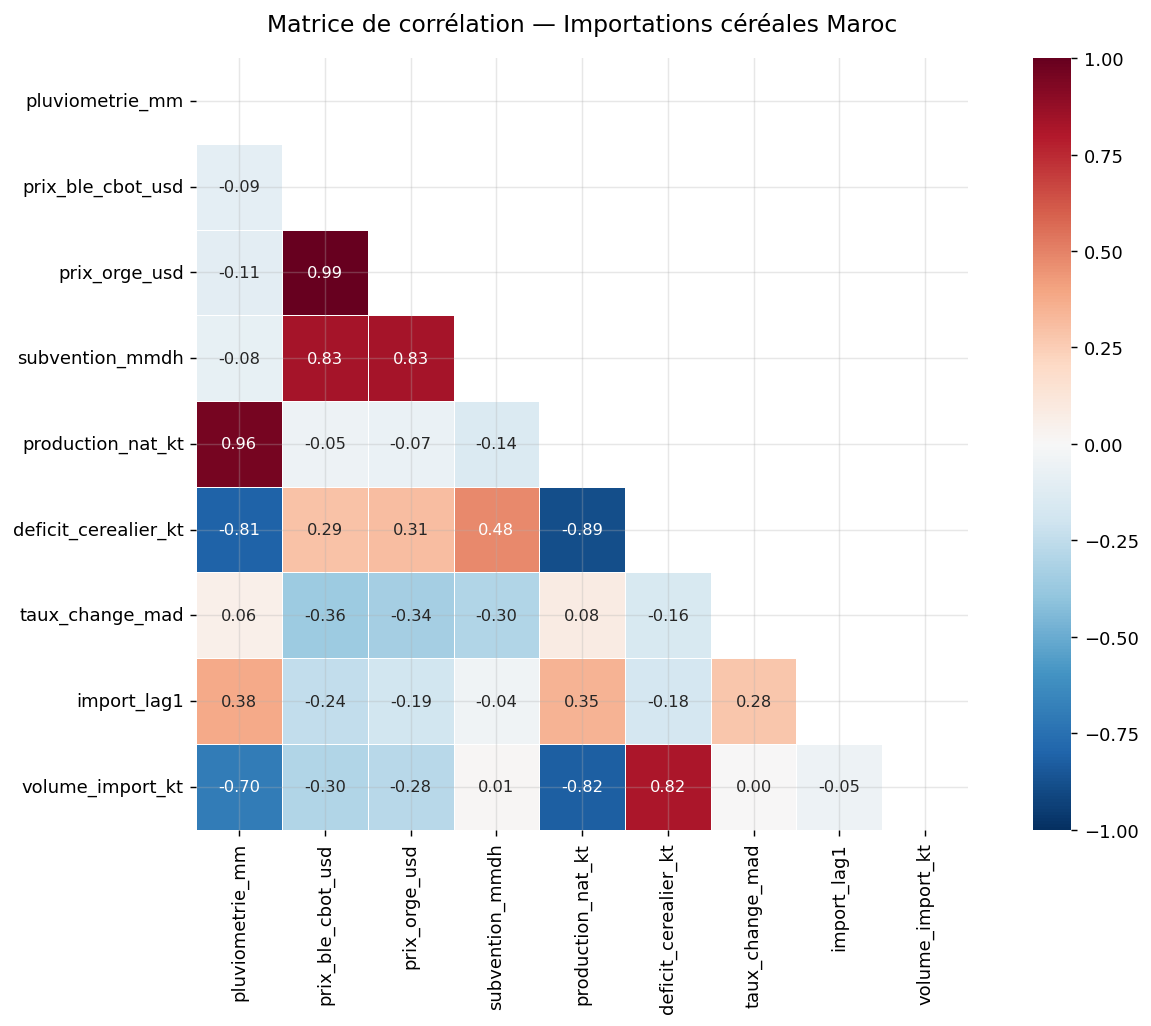


🔗 Corrélations avec volume_import_kt :
production_nat_kt      -0.824
deficit_cerealier_kt    0.817
pluviometrie_mm        -0.700
prix_ble_cbot_usd      -0.302
prix_orge_usd          -0.278
import_lag1            -0.052
subvention_mmdh         0.014
taux_change_mad         0.000
Name: volume_import_kt, dtype: float64


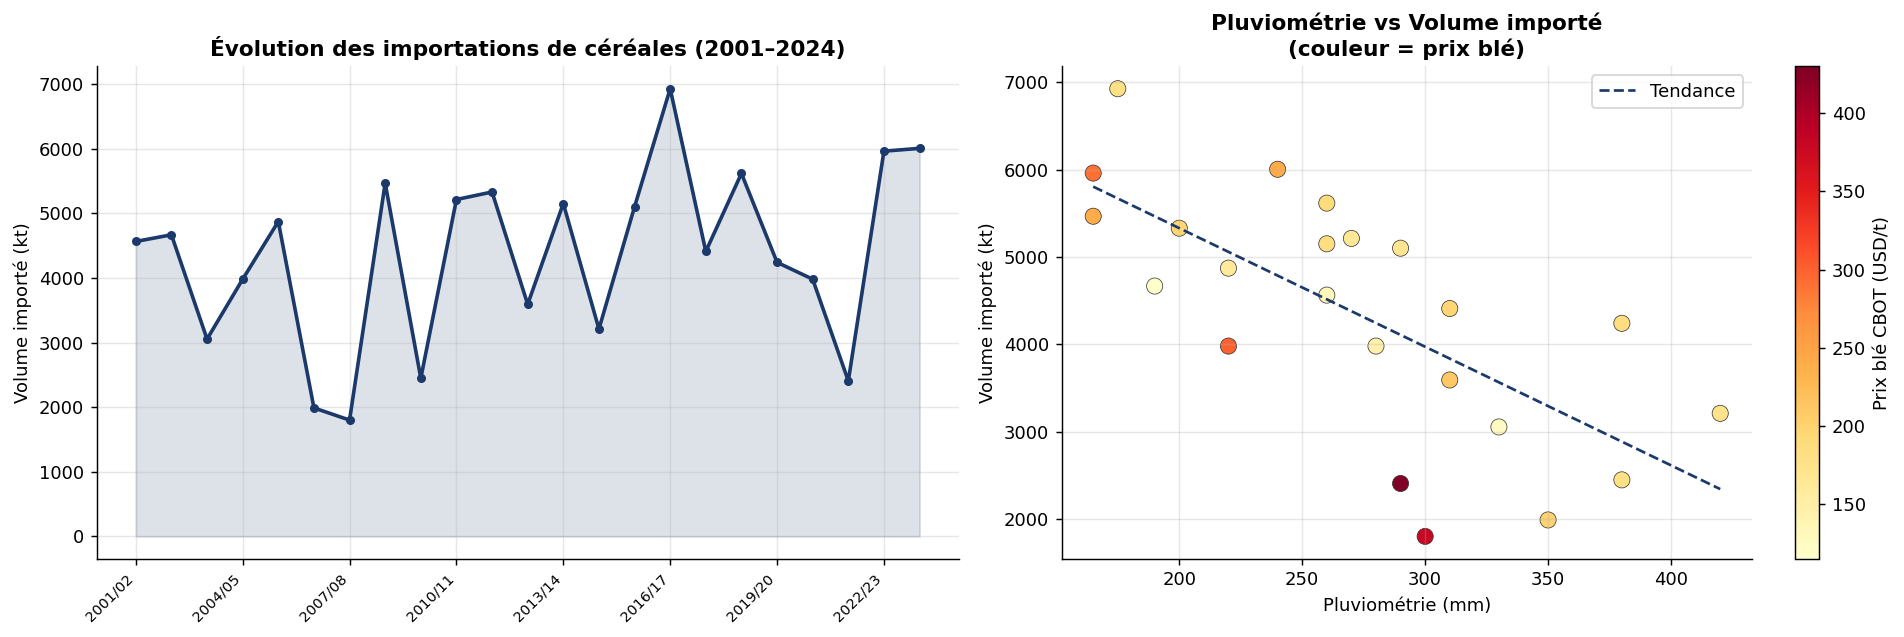

✅ Analyse exploratoire terminée
📦 Train : 18 observations (2001/02 → 2018/19)
🧪 Test  : 5  observations (2019/20 → 2023/24)
📐 Features : ['pluviometrie_mm', 'prix_ble_cbot_usd', 'prix_orge_usd', 'subvention_mmdh', 'production_nat_kt', 'deficit_cerealier_kt', 'taux_change_mad', 'import_lag1']
                            OLS Regression Results                            
Dep. Variable:       volume_import_kt   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     195.6
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.56e-09
Time:                        14:24:25   Log-Likelihood:                -108.63
No. Observations:                  18   AIC:                             235.3
Df Residuals:                       9   BIC:                             243.3
Df Model:                           8                                      

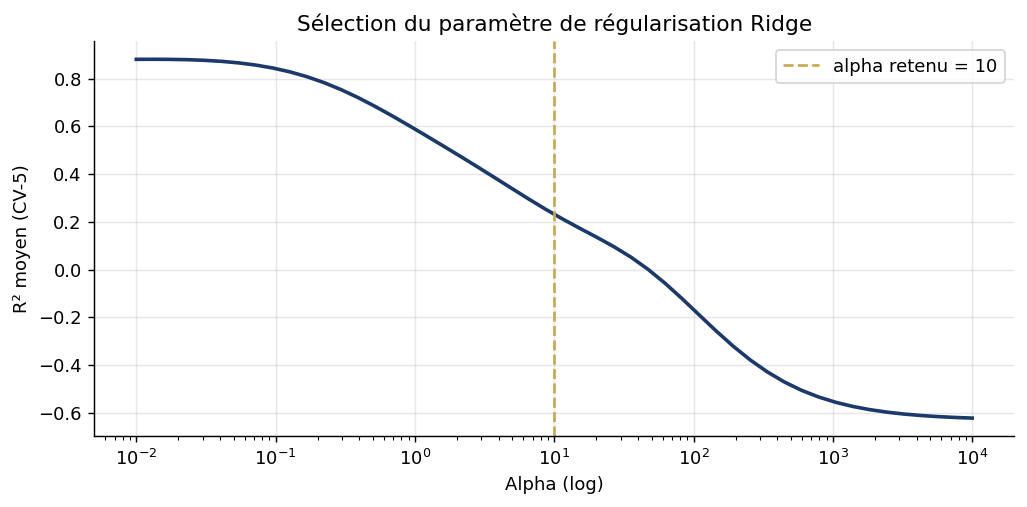

✅ Meilleur alpha (CV) : 0.01
✅ Random Forest entraîné (200 arbres)

📊 COMPARAISON DES MODÈLES

                           RMSE (kt)  MAE (kt)      R²  MAPE (%)
Modèle                                                          
Régression Linéaire (OLS)      178.6     135.8  0.9825      3.86
Ridge (alpha=10)               534.3     506.8  0.8436     12.89
Random Forest (n=200)         1275.8    1156.4  0.1080     32.69


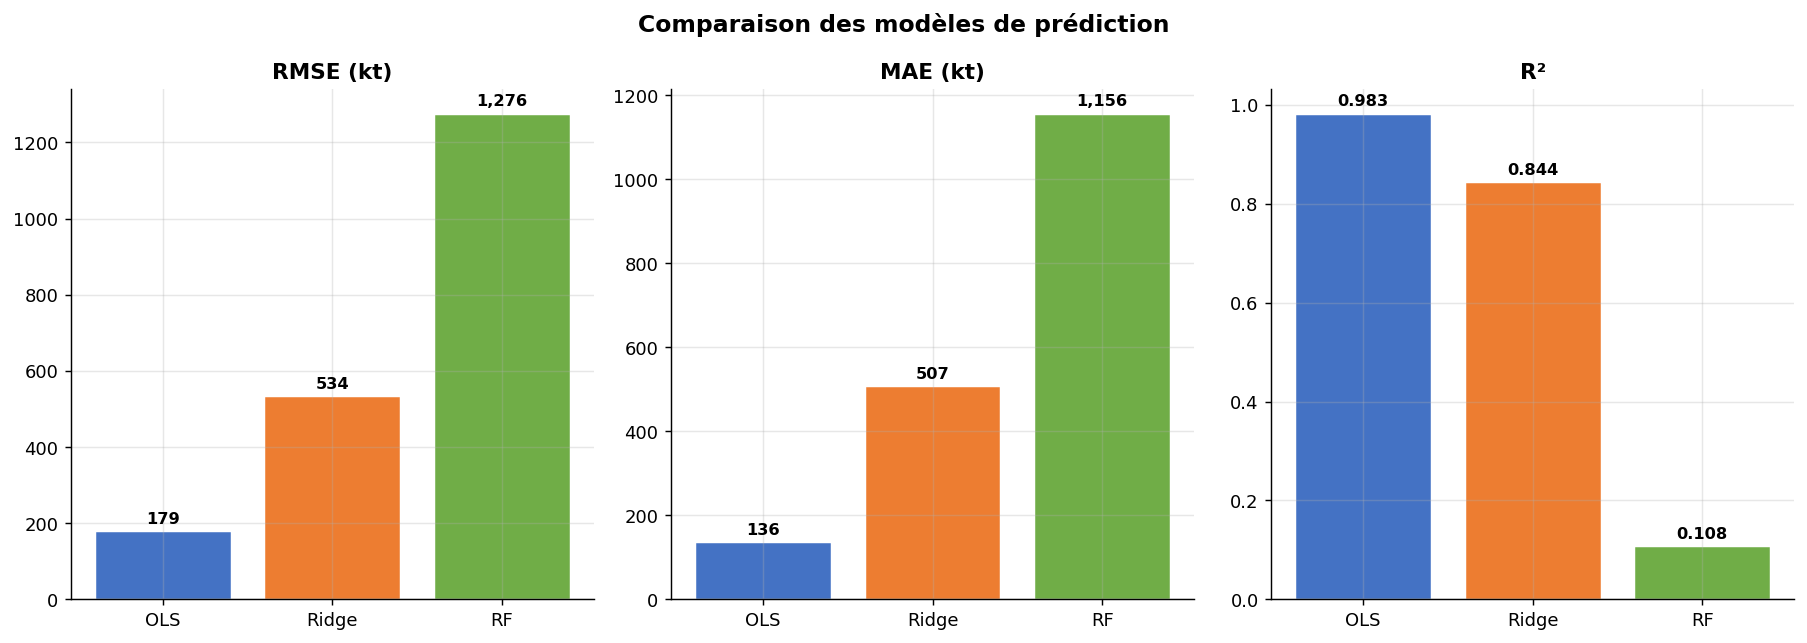

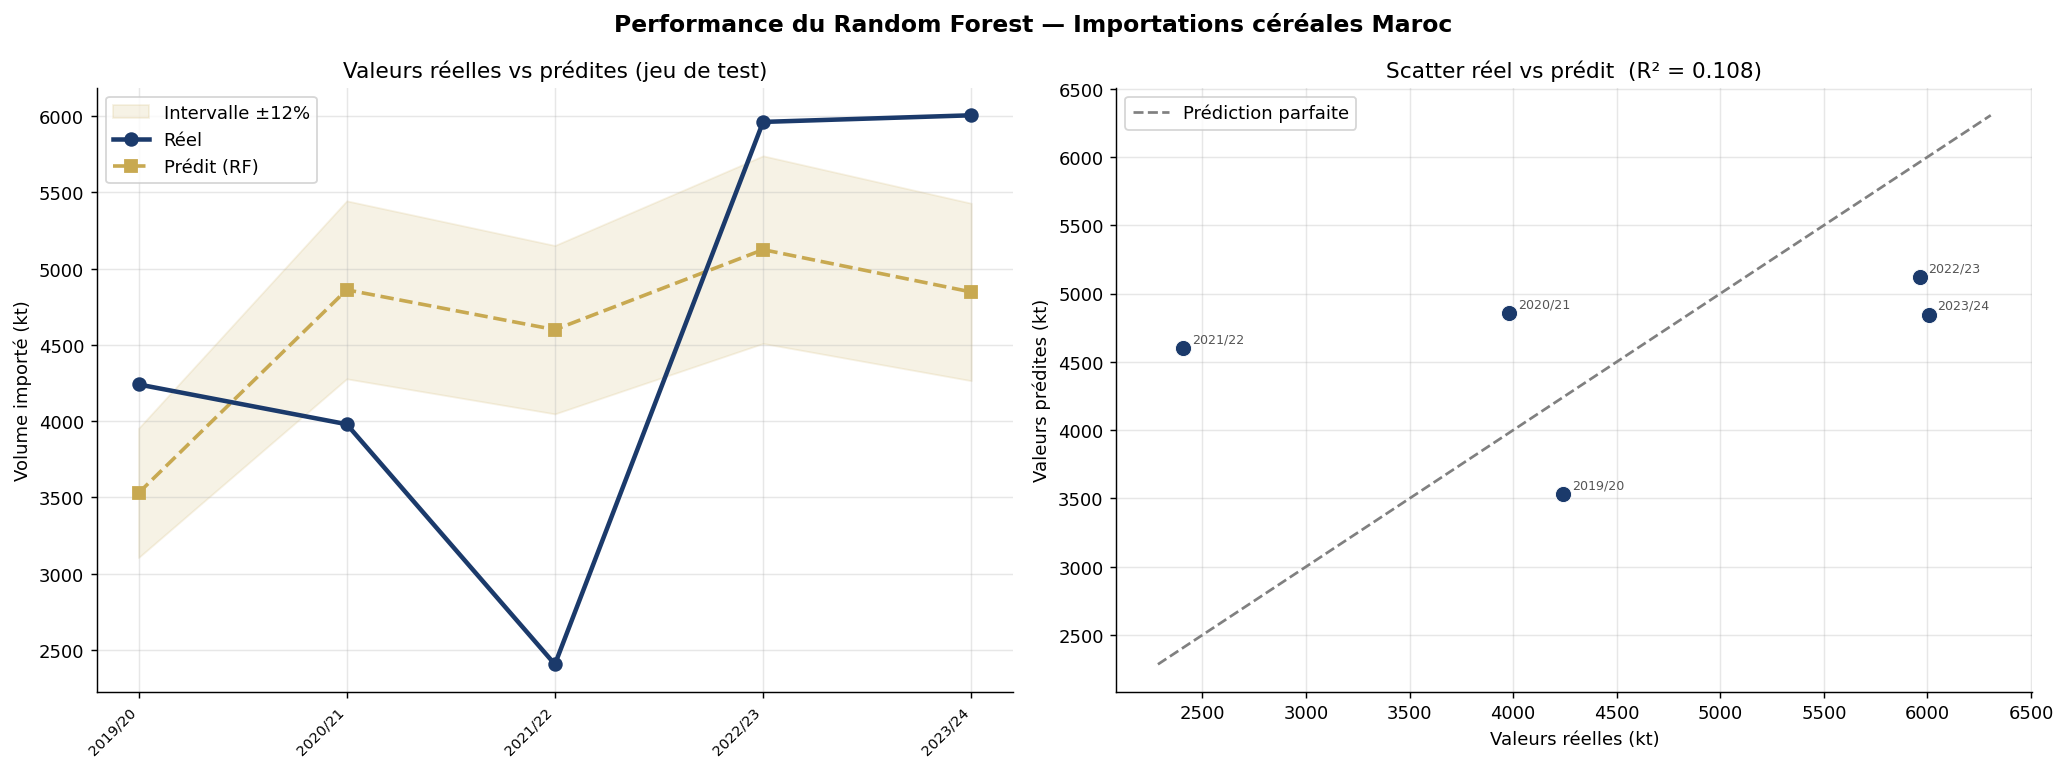

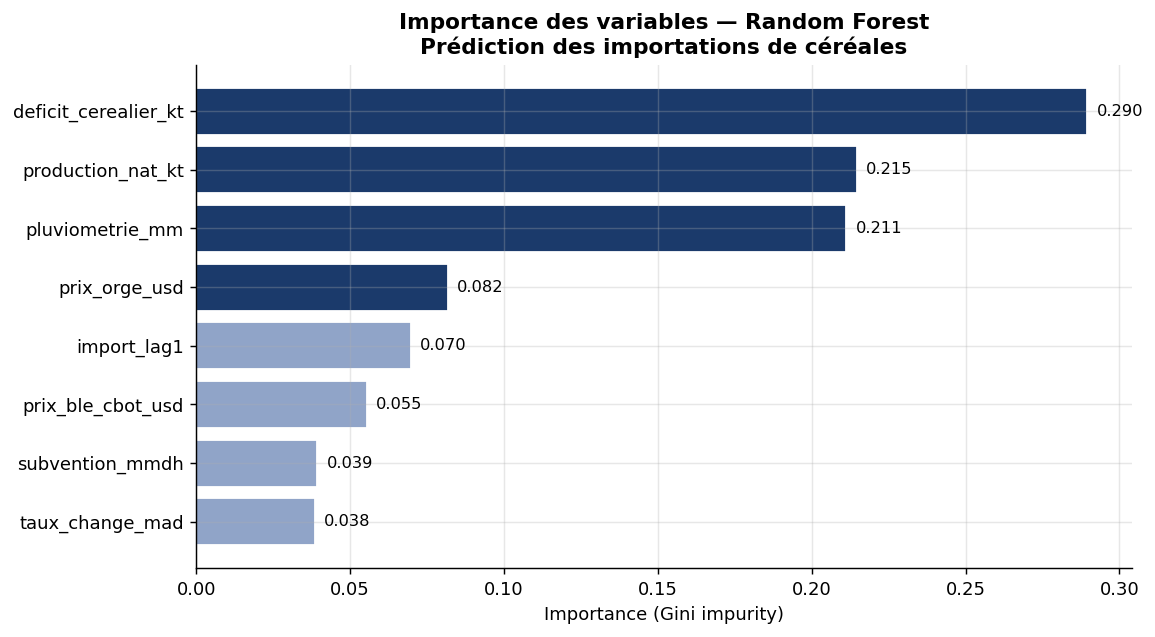


📌 Variables les plus importantes :
  deficit_cerealier_kt           : 29.0%
  production_nat_kt              : 21.5%
  pluviometrie_mm                : 21.1%
  prix_orge_usd                  : 8.2%
  import_lag1                    : 7.0%
  prix_ble_cbot_usd              : 5.5%
  subvention_mmdh                : 3.9%
  taux_change_mad                : 3.8%


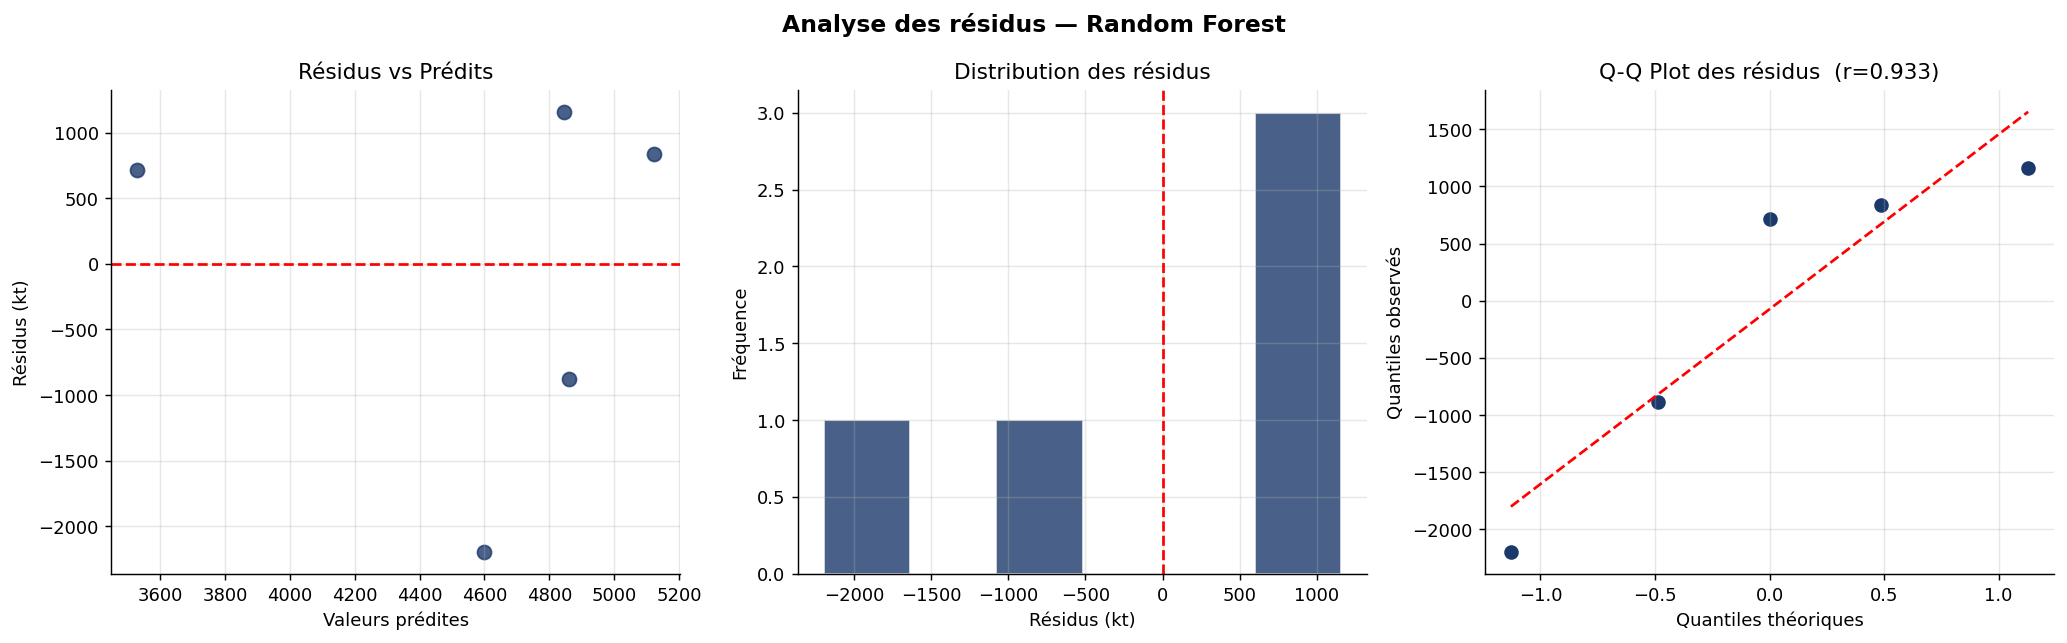


📊 Statistiques des résidus :
  Moyenne    :      -73.5 kt
  Écart-type :     1273.7 kt
  Min / Max  :    -2193.7 / 1158.3 kt

🔁 VALIDATION CROISÉE (KFold n=5)

  OLS       R²=0.942 ±0.054   RMSE=     201 ±    72
  Ridge     R²=0.544 ±0.384   RMSE=     651 ±   207
  RF        R²=0.340 ±0.340   RMSE=     950 ±   450

🔮 SIMULATION — Prédiction campagne 2024/25

  🔴 Scénario sécheresse  → Volume prédit :    4,928 kt
  🟢 Scénario bonne année → Volume prédit :    2,805 kt
  📉 Écart entre scénarios :  2,123 kt


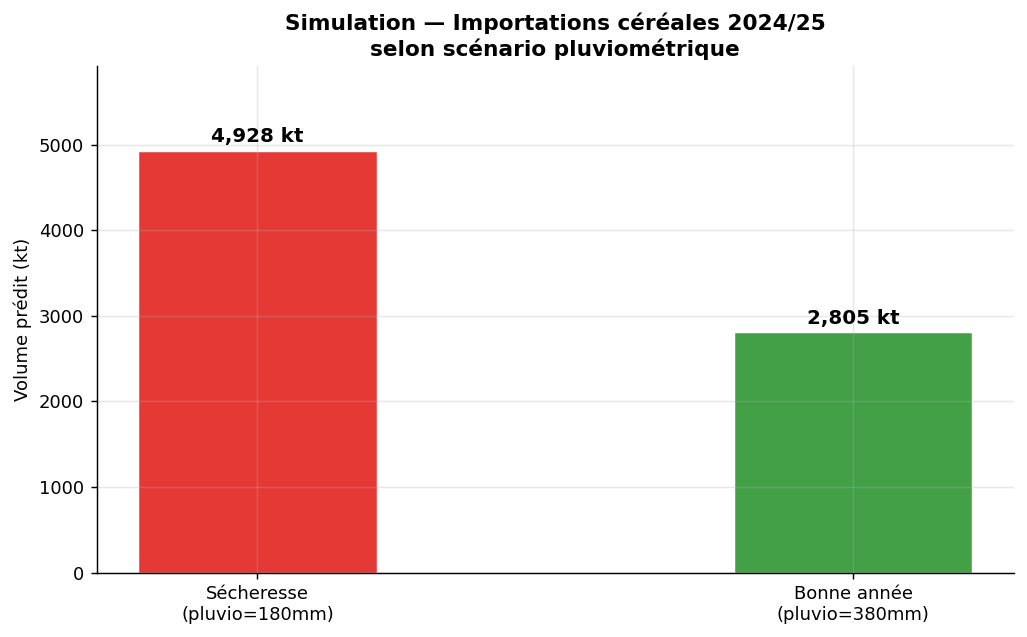


✅ Fichiers exportés :
   → resultats_predictions_cereales.csv
   → metriques_modeles.csv

🎓 FIN DU SCRIPT — ENCG Settat CI S5
   Meilleur modèle : Random Forest  (R² = 0.1080)


In [1]:
# ============================================================
#  ENCG SETTAT — Commerce International S5
#  Prédiction des Importations de Céréales au Maroc
#  (Blé & Orge) — Modèles de Régression

# ============================================================

# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 1 — Installation des dépendances               ║
# ╚══════════════════════════════════════════════════════════╝
# !pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels openpyxl


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Import des bibliothèques                   ║
# ╚══════════════════════════════════════════════════════════╝
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Style global des graphiques
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("✅ Bibliothèques importées avec succès")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Génération du dataset simulé               ║
# ║  (remplace par ton vrai CSV si disponible)              ║
# ╚══════════════════════════════════════════════════════════╝
np.random.seed(42)
n = 24  # campagnes 2000/01 → 2023/24

campagnes = [f"{2000+i}/{str(2001+i)[-2:]}" for i in range(n)]

# --- Pluviométrie (mm) : moyenne ~285 mm, forte variabilité
pluvio = np.array([310, 260, 190, 330, 280, 220, 350, 300, 165,
                   380, 270, 200, 310, 260, 420, 290, 175, 310,
                   260, 380, 220, 290, 165, 240])

# --- Production nationale (milliers de tonnes)
production = np.clip(pluvio * 18 + np.random.normal(0, 400, n), 1000, 11500)

# --- Besoins totaux (croissance démographique ~1.1%/an)
besoins = np.array([8500 + i * 110 for i in range(n)]) + np.random.normal(0, 200, n)

# --- Déficit céréalier
deficit = besoins - production

# --- Prix blé CBOT (USD/tonne)
prix_ble = np.array([120, 130, 115, 125, 145, 160, 200, 380,
                     240, 180, 165, 195, 210, 185, 175, 170,
                     180, 195, 190, 185, 300, 430, 290, 240])

# --- Prix orge (USD/tonne)
prix_orge = prix_ble * 0.78 + np.random.normal(0, 8, n)

# --- Taux de change MAD/USD
taux_change = np.array([10.5, 10.6, 10.8, 10.9, 11.0, 10.8, 10.6, 10.4,
                        10.3, 10.5, 10.7, 10.9, 11.0, 10.8, 10.6, 10.5,
                        10.4, 10.6, 10.7, 10.8, 10.9, 10.5, 10.6, 10.7])

# --- Subvention Caisse de Compensation (Milliards MAD)
subvention = np.array([2.1, 2.3, 2.5, 2.4, 2.6, 3.0, 3.5, 5.2,
                       4.8, 4.0, 3.8, 4.2, 5.0, 4.6, 4.3, 4.1,
                       4.0, 4.2, 4.3, 4.5, 5.1, 6.2, 5.8, 5.3])

# --- Volume importé (variable cible, milliers de tonnes)
# Logique : plus le déficit est grand, plus on importe
volume_import = (
    deficit * 0.85
    + (prix_ble - 180) * (-12)
    + subvention * 120
    + (taux_change - 10.6) * (-150)
    + np.random.normal(0, 180, n)
)
volume_import = np.clip(volume_import, 1800, 7200)

# --- Création du DataFrame
df = pd.DataFrame({
    'campagne':          campagnes,
    'pluviometrie_mm':   pluvio,
    'production_nat_kt': production,
    'besoins_totaux_kt': besoins,
    'deficit_cerealier_kt': deficit,
    'prix_ble_cbot_usd': prix_ble,
    'prix_orge_usd':     prix_orge,
    'taux_change_mad':   taux_change,
    'subvention_mmdh':   subvention,
    'volume_import_kt':  volume_import,
})

# Feature lag : volume importé campagne précédente
df['import_lag1'] = df['volume_import_kt'].shift(1)
df = df.dropna().reset_index(drop=True)

print(f"✅ Dataset généré : {df.shape[0]} campagnes × {df.shape[1]} variables")
print(df.head())


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Statistiques descriptives                  ║
# ╚══════════════════════════════════════════════════════════╝
print("\n📊 STATISTIQUES DESCRIPTIVES\n")
desc = df.describe().round(1)
print(desc)

# Histogrammes des principales variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribution des variables — Importations céréales Maroc", fontsize=14, fontweight='bold')

cols_hist = ['volume_import_kt', 'pluviometrie_mm', 'production_nat_kt',
             'prix_ble_cbot_usd', 'deficit_cerealier_kt', 'subvention_mmdh']
couleurs = ['#1B3A6B', '#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for ax, col, col_c in zip(axes.flat, cols_hist, couleurs):
    ax.hist(df[col], bins=8, color=col_c, alpha=0.75, edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.set_xlabel("Valeur")
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()
print("✅ Histogrammes affichés")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 5 — Matrice de corrélation                     ║
# ╚══════════════════════════════════════════════════════════╝
features = ['pluviometrie_mm', 'prix_ble_cbot_usd', 'prix_orge_usd',
            'subvention_mmdh', 'production_nat_kt', 'deficit_cerealier_kt',
            'taux_change_mad', 'import_lag1']
target = 'volume_import_kt'

corr_matrix = df[features + [target]].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    square=True, vmin=-1, vmax=1,
    annot_kws={"size": 9}
)
plt.title("Matrice de corrélation — Importations céréales Maroc", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Top corrélations avec la cible
print("\n🔗 Corrélations avec volume_import_kt :")
print(corr_matrix[target].drop(target).sort_values(key=abs, ascending=False).round(3))


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 6 — Analyse exploratoire visuelle              ║
# ╚══════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1 : Évolution du volume importé
ax = axes[0]
x = range(len(df))
ax.fill_between(x, df['volume_import_kt'], alpha=0.15, color='#1B3A6B')
ax.plot(x, df['volume_import_kt'], 'o-', color='#1B3A6B', linewidth=2, markersize=4)
ax.set_xticks(x[::3])
ax.set_xticklabels(df['campagne'].iloc[::3], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Volume importé (kt)")
ax.set_title("Évolution des importations de céréales (2001–2024)", fontweight='bold')

# Graphique 2 : Scatter pluvio vs import
ax = axes[1]
scatter = ax.scatter(df['pluviometrie_mm'], df['volume_import_kt'],
                     c=df['prix_ble_cbot_usd'], cmap='YlOrRd',
                     s=80, edgecolors='#333', linewidth=0.4)
plt.colorbar(scatter, ax=ax, label="Prix blé CBOT (USD/t)")
z = np.polyfit(df['pluviometrie_mm'], df['volume_import_kt'], 1)
p = np.poly1d(z)
ax.plot(sorted(df['pluviometrie_mm']), p(sorted(df['pluviometrie_mm'])),
        '--', color='#1B3A6B', linewidth=1.5, label='Tendance')
ax.set_xlabel("Pluviométrie (mm)")
ax.set_ylabel("Volume importé (kt)")
ax.set_title("Pluviométrie vs Volume importé\n(couleur = prix blé)", fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()
print("✅ Analyse exploratoire terminée")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 7 — Préparation du jeu de données              ║
# ╚══════════════════════════════════════════════════════════╝
X = df[features]
y = df[target]

# Split chronologique (pas de data leakage !)
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"📦 Train : {len(X_train)} observations ({df['campagne'].iloc[0]} → {df['campagne'].iloc[split_idx-1]})")
print(f"🧪 Test  : {len(X_test)}  observations ({df['campagne'].iloc[split_idx]} → {df['campagne'].iloc[-1]})")
print(f"📐 Features : {features}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 8 — Modèle 1 : Régression Linéaire (OLS)      ║
# ╚══════════════════════════════════════════════════════════╝
ols_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
ols_pipe.fit(X_train, y_train)
y_pred_ols = ols_pipe.predict(X_test)

# Statsmodels pour les p-values
X_train_sm = sm.add_constant(StandardScaler().fit_transform(X_train))
ols_sm = sm.OLS(y_train, X_train_sm).fit()
print(ols_sm.summary())


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 9 — Modèle 2 : Ridge                          ║
# ╚══════════════════════════════════════════════════════════╝
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)

# Courbe de validation alpha
alphas = np.logspace(-2, 4, 50)
cv_scores = []
for a in alphas:
    pipe = Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=a))])
    s = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    cv_scores.append(s.mean())

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, cv_scores, color='#1B3A6B', linewidth=2)
plt.axvline(10.0, color='#C8A951', linestyle='--', label='alpha retenu = 10')
plt.xlabel("Alpha (log)")
plt.ylabel("R² moyen (CV-5)")
plt.title("Sélection du paramètre de régularisation Ridge")
plt.legend()
plt.tight_layout()
plt.show()
print(f"✅ Meilleur alpha (CV) : {alphas[np.argmax(cv_scores)]:.2f}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 10 — Modèle 3 : Random Forest                 ║
# ╚══════════════════════════════════════════════════════════╝
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("✅ Random Forest entraîné (200 arbres)")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 11 — Comparaison des performances              ║
# ╚══════════════════════════════════════════════════════════╝
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Modèle': name, 'RMSE (kt)': round(rmse, 1),
            'MAE (kt)': round(mae, 1), 'R²': round(r2, 4),
            'MAPE (%)': round(mape, 2)}

results = [
    evaluate_model("Régression Linéaire (OLS)", y_test, y_pred_ols),
    evaluate_model("Ridge (alpha=10)",          y_test, y_pred_ridge),
    evaluate_model("Random Forest (n=200)",     y_test, y_pred_rf),
]
results_df = pd.DataFrame(results).set_index('Modèle')

print("\n📊 COMPARAISON DES MODÈLES\n")
print(results_df.to_string())

# Bar chart comparatif
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparaison des modèles de prédiction", fontsize=13, fontweight='bold')

colors = ['#4472C4', '#ED7D31', '#70AD47']
for ax, metric in zip(axes, ['RMSE (kt)', 'MAE (kt)', 'R²']):
    vals = results_df[metric]
    bars = ax.bar(range(3), vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(3))
    ax.set_xticklabels(['OLS', 'Ridge', 'RF'], fontsize=10)
    ax.set_title(metric, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.3f}' if metric == 'R²' else f'{v:,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 12 — Graphique Prédit vs Réel (Random Forest) ║
# ╚══════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Performance du Random Forest — Importations céréales Maroc",
             fontsize=13, fontweight='bold')

# Subplot 1 : Séries temporelles
ax = axes[0]
camp_test = df['campagne'].iloc[split_idx:].values
x_test_idx = range(len(camp_test))

ax.fill_between(x_test_idx,
                y_pred_rf * 0.88, y_pred_rf * 1.12,
                alpha=0.15, color='#C8A951', label='Intervalle ±12%')
ax.plot(x_test_idx, y_test.values, 'o-', color='#1B3A6B',
        linewidth=2.5, markersize=7, label='Réel', zorder=5)
ax.plot(x_test_idx, y_pred_rf, 's--', color='#C8A951',
        linewidth=2, markersize=7, label='Prédit (RF)', zorder=4)

ax.set_xticks(x_test_idx)
ax.set_xticklabels(camp_test, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Volume importé (kt)")
ax.set_title("Valeurs réelles vs prédites (jeu de test)")
ax.legend()

# Subplot 2 : Scatter réel vs prédit
ax = axes[1]
min_val = min(y_test.min(), y_pred_rf.min()) * 0.95
max_val = max(y_test.max(), y_pred_rf.max()) * 1.05
ax.plot([min_val, max_val], [min_val, max_val], '--', color='gray',
        linewidth=1.5, label='Prédiction parfaite')
ax.scatter(y_test, y_pred_rf, color='#1B3A6B', s=80,
           edgecolors='white', linewidth=0.5, zorder=5)

# Annoter les points avec les campagnes
for xi, yi, camp in zip(y_test.values, y_pred_rf, camp_test):
    ax.annotate(camp, (xi, yi), textcoords="offset points",
                xytext=(5, 3), fontsize=7, color='#555')

ax.set_xlabel("Valeurs réelles (kt)")
ax.set_ylabel("Valeurs prédites (kt)")
ax.set_title(f"Scatter réel vs prédit  (R² = {r2_score(y_test, y_pred_rf):.3f})")
ax.legend()

plt.tight_layout()
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 13 — Importance des variables                  ║
# ╚══════════════════════════════════════════════════════════╝
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values()
colors_imp = ['#1B3A6B' if v > feat_imp.median() else '#90A4C8' for v in feat_imp]

plt.figure(figsize=(9, 5))
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='white')
plt.xlabel("Importance (Gini impurity)")
plt.title("Importance des variables — Random Forest\nPrédiction des importations de céréales", fontweight='bold')

for bar, val in zip(bars, feat_imp.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📌 Variables les plus importantes :")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {feat:<30s} : {imp*100:.1f}%")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 14 — Analyse des résidus                       ║
# ╚══════════════════════════════════════════════════════════╝
residus = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Analyse des résidus — Random Forest", fontsize=13, fontweight='bold')

# Résidus vs prédits
axes[0].scatter(y_pred_rf, residus, color='#1B3A6B', s=60, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Résidus (kt)")
axes[0].set_title("Résidus vs Prédits")

# Distribution des résidus
axes[1].hist(residus, bins=6, color='#1B3A6B', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Résidus (kt)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des résidus")

# QQ-plot manuel
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residus, dist="norm")
axes[2].scatter(osm, osr, color='#1B3A6B', s=50)
axes[2].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[2].set_xlabel("Quantiles théoriques")
axes[2].set_ylabel("Quantiles observés")
axes[2].set_title(f"Q-Q Plot des résidus  (r={r:.3f})")

plt.tight_layout()
plt.show()

print(f"\n📊 Statistiques des résidus :")
print(f"  Moyenne    : {residus.mean():>10.1f} kt")
print(f"  Écart-type : {residus.std():>10.1f} kt")
print(f"  Min / Max  : {residus.min():>10.1f} / {residus.max():.1f} kt")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 15 — Validation croisée (CV-5)                 ║
# ╚══════════════════════════════════════════════════════════╝
print("\n🔁 VALIDATION CROISÉE (KFold n=5)\n")
kf = KFold(n_splits=5, shuffle=False)  # pas de shuffle pour données temporelles

modeles = {
    'OLS':   ols_pipe,
    'Ridge': ridge_pipe,
    'RF':    rf_model,
}

for nom, modele in modeles.items():
    scores_r2   = cross_val_score(modele, X, y, cv=kf, scoring='r2')
    scores_rmse = np.sqrt(-cross_val_score(modele, X, y, cv=kf,
                                            scoring='neg_mean_squared_error'))
    print(f"  {nom:8s}  R²={scores_r2.mean():.3f} ±{scores_r2.std():.3f}"
          f"   RMSE={scores_rmse.mean():>8,.0f} ±{scores_rmse.std():>6,.0f}")


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 16 — Prédiction d'une nouvelle campagne        ║
# ╚══════════════════════════════════════════════════════════╝
print("\n🔮 SIMULATION — Prédiction campagne 2024/25\n")

# Scénario : pluviométrie faible (année de sécheresse)
scenario_seche = pd.DataFrame([{
    'pluviometrie_mm':     180,
    'prix_ble_cbot_usd':   260,
    'prix_orge_usd':       200,
    'subvention_mmdh':     5.5,
    'production_nat_kt':   3200,
    'deficit_cerealier_kt': 7100,
    'taux_change_mad':     10.8,
    'import_lag1':         df['volume_import_kt'].iloc[-1]
}])

# Scénario : bonne pluviométrie
scenario_bon = pd.DataFrame([{
    'pluviometrie_mm':     380,
    'prix_ble_cbot_usd':   240,
    'prix_orge_usd':       185,
    'subvention_mmdh':     4.5,
    'production_nat_kt':   8500,
    'deficit_cerealier_kt': 1800,
    'taux_change_mad':     10.7,
    'import_lag1':         df['volume_import_kt'].iloc[-1]
}])

pred_seche = rf_model.predict(scenario_seche)[0]
pred_bon   = rf_model.predict(scenario_bon)[0]

print(f"  🔴 Scénario sécheresse  → Volume prédit : {pred_seche:>8,.0f} kt")
print(f"  🟢 Scénario bonne année → Volume prédit : {pred_bon:>8,.0f} kt")
print(f"  📉 Écart entre scénarios : {abs(pred_seche - pred_bon):>6,.0f} kt")

# Visualisation des scénarios
fig, ax = plt.subplots(figsize=(8, 5))
scenarios = ['Sécheresse\n(pluvio=180mm)', 'Bonne année\n(pluvio=380mm)']
valeurs   = [pred_seche, pred_bon]
cols      = ['#E53935', '#43A047']
bars = ax.bar(scenarios, valeurs, color=cols, edgecolor='white',
              linewidth=0.8, width=0.4)

for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f} kt', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel("Volume prédit (kt)")
ax.set_title("Simulation — Importations céréales 2024/25\nselon scénario pluviométrique",
             fontweight='bold')
ax.set_ylim(0, max(valeurs) * 1.2)
plt.tight_layout()
plt.show()


# ╔══════════════════════════════════════════════════════════╗
# ║  CELLULE 17 — Export des résultats                      ║
# ╚══════════════════════════════════════════════════════════╝
# Export du dataset avec prédictions
df_test = df.iloc[split_idx:].copy()
df_test['pred_ols']   = y_pred_ols
df_test['pred_ridge'] = y_pred_ridge
df_test['pred_rf']    = y_pred_rf
df_test['erreur_rf']  = df_test['volume_import_kt'] - df_test['pred_rf']

df_test.to_csv('resultats_predictions_cereales.csv', index=False, sep=';')
results_df.to_csv('metriques_modeles.csv', sep=';')

print("\n✅ Fichiers exportés :")
print("   → resultats_predictions_cereales.csv")
print("   → metriques_modeles.csv")
print("\n🎓 FIN DU SCRIPT — ENCG Settat CI S5")
print(f"   Meilleur modèle : Random Forest  (R² = {r2_score(y_test, y_pred_rf):.4f})")